# Импорт библиотек #

In [1]:
import shutil
import os
import numpy as np
import pandas as pd
import yaml
import cv2


from clearml import Task 


import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


from ultralytics import YOLO


import torch
import torchvision
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F
from torchvision import transforms, models
from torchvision.ops import box_iou
from torchmetrics import JaccardIndex
from torchvision.models.detection.anchor_utils import AnchorGenerator


from sklearn.model_selection import train_test_split

from tqdm import tqdm

from colorama import Fore

from PIL import Image, ImageDraw

import contextlib
import gc

## Связываем сервер clearML для сохранения результатов обучения ##

In [4]:
# Связывает логирование обучения (выводов в консоль) и аккаунт в clearML

%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=TNG2NF9Z65L0E6GKXGAFE48IQKZF9A
%env CLEARML_API_SECRET_KEY=QXnW1wsyPX_jpF8ZyvHzIfotmewBkO2UXq0yl8ywo0ASmR0cyTAnDys4bTMjB_rUNfs

task = Task.init(project_name="Project Tests", task_name="YOLO_1280_AFTER-TRAINING_newAUG")

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=TNG2NF9Z65L0E6GKXGAFE48IQKZF9A
env: CLEARML_API_SECRET_KEY=QXnW1wsyPX_jpF8ZyvHzIfotmewBkO2UXq0yl8ywo0ASmR0cyTAnDys4bTMjB_rUNfs
ClearML Task: created new task id=20d56a83860d4d4d901fddea8a293591
2024-12-05 19:15:23,137 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML results page: https://app.clear.ml/projects/da1a3426c4294807aa46d570af719669/experiments/20d56a83860d4d4d901fddea8a293591/output/log
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start
ClearML Monitor: Reporting detected, reverting back to iteration based reporting


# Обучение модели YOLO #

In [5]:
def my_train ():
    model = YOLO("final_test/YOLO_1280_AFTER-TRAINING/weights/last.pt")
    model.train(
        # Проект, модель
        project="final_test",
        name="YOLO_1280_AFTER-TRAINING_newAUG",

        # Данные
        data="datasets/my_data_1/config.yaml", 

        
        # Random Seed parameters
        deterministic=True,
        seed=42,
    
        # Параметры модели
        save=True,
        save_period=5,
        pretrained=True,
        imgsz=1280,
    
        # Параметры обучения
        epochs=50,
        batch=5,
        workers=4,
        val=True,
        device=0,
        amp = False,
        single_cls = True,
        lr0 = 0.02,
        lrf = 0.012,
        optimizer = 'AdamW',
        #dropout = 0.1,
        box = 8,
        mosaic = 1,
        mixup = 1
        
    )

In [6]:
import contextlib
import gc

@contextlib.contextmanager
def clear_memory():
    try:
        yield
    finally:
        gc.collect()

with clear_memory():
    my_train()

New https://pypi.org/project/ultralytics/8.3.40 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.39  Python-3.12.7 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
engine\trainer: task=detect, mode=train, model=final_test/YOLO_1280_AFTER-TRAINING/weights/last.pt, data=datasets/my_data_1/config.yaml, epochs=50, time=None, patience=100, batch=5, imgsz=1280, save=True, save_period=5, cache=False, device=0, workers=4, project=final_test, name=YOLO_1280_AFTER-TRAINING_newAUG, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=True, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=False, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agno

train: Scanning C:\Anaconda_notebooks\datasets\my_data_1\labels\train...:   0%|          | 0/6552 [00:00<?, ?it/s]Scanning C:\Anaconda_notebooks\datasets\my_data_1\labels\train... 91 images, 0 backgrounds, 0 corrupt:   1%|▏   Scanning C:\Anaconda_notebooks\datasets\my_data_1\labels\train... 180 images, 1 backgrounds, 0 corrupt:   3%|▎  Scanning C:\Anaconda_notebooks\datasets\my_data_1\labels\train... 263 images, 3 backgrounds, 0 corrupt:   4%|▍  Scanning C:\Anaconda_notebooks\datasets\my_data_1\labels\train... 355 images, 3 backgrounds, 0 corrupt:   5%|▌  Scanning C:\Anaconda_notebooks\datasets\my_data_1\labels\train... 452 images, 3 backgrounds, 0 corrupt:   7%|▋  Scanning C:\Anaconda_notebooks\datasets\my_data_1\labels\train... 556 images, 4 backgrounds, 0 corrupt:   8%|▊  Scanning C:\Anaconda_notebooks\datasets\my_data_1\labels\train... 658 images, 7 backgrounds, 0 corrupt:  10%|█  Scanning C:\Anaconda_notebooks\datasets\my_data_1\labels\train... 756 images, 7 backgrounds, 0 corrupt

train: New cache created: C:\Anaconda_notebooks\datasets\my_data_1\labels\train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning C:\Anaconda_notebooks\datasets\my_data_1\labels\val.cache... 273 images, 0 backgrounds, 0 corrupt: 100%|█Scanning C:\Anaconda_notebooks\datasets\my_data_1\labels\val.cache... 273 images, 0 backgrounds, 0 corrupt: 100%|█


Plotting labels to final_test\YOLO_1280_AFTER-TRAINING_newAUG\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005078125), 87 bias(decay=0.0)
Image sizes 1280 train, 1280 val
Using 4 dataloader workers
Logging results to final_test\YOLO_1280_AFTER-TRAINING_newAUG
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all        273        831       0.93      0.905      0.943      0.617

50 epochs completed in 4.510 hours.
Optimizer stripped from final_test\YOLO_1280_AFTER-TRAINING_newAUG\weights\last.pt, 5.6MB
Optimizer stripped from final_test\YOLO_1280_AFTER-TRAINING_newAUG\weights\best.pt, 5.6MB

Validating final_test\YOLO_1280_AFTER-TRAINING_newAUG\weights\best.pt...
Ultralytics 8.3.39  Python-3.12.7 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
YOLO11n summary (fused): 238 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 28/28 [00:05


                   all        273        831       0.93      0.911      0.945      0.619
Speed: 0.6ms preprocess, 4.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to final_test\YOLO_1280_AFTER-TRAINING_newAUG
2024-12-05 23:47:12,142 - clearml.storage - INFO - Starting upload: final_test\YOLO_1280_AFTER-TRAINING_newAUG\weights\best.pt => https://files.clear.ml/Project Tests/YOLO_1280_AFTER-TRAINING_newAUG.20d56a83860d4d4d901fddea8a293591/models/best.pt
2024-12-05 23:47:22,410 - clearml.storage - INFO - Uploading: 5.32MB to final_test\YOLO_1280_AFTER-TRAINING_newAUG\weights\best.pt


████████████████████████████████▉ 100% | 5.31/5.32 MB [00:10<00:00,  1.97s/MB]: C:\Users\mrsli\anaconda3\envs\research_env\Lib\site-packages\tqdm\std.py:636: TqdmWarning:

clamping frac to range [0, 1]

█████████████████████████████████ 100% | 5.32/5.32 MB [00:10<00:00,  2.05s/MB]: 


2024-12-05 23:47:33,330 - clearml.Task - INFO - Completed model upload to https://files.clear.ml/Project%20Tests/YOLO_1280_AFTER-TRAINING_newAUG.20d56a83860d4d4d901fddea8a293591/models/best.pt


# Валидация(тестирование) модели YOLO #

In [3]:
# Вывести данные по валидации модели (только по val выборке, указанной в config.yaml)


models = [
    YOLO('final_test/YOLO_1280_AFTER-TRAINING_newAUG/weights/best.pt'),
    #YOLO('final_test/yolo_n-640x640-no_aug/weights/best.pt'),
    #YOLO('final_test/yolo_n-1280x1280-no_aug/weights/best.pt'),
    #YOLO('final_test/yolo_n-2080x2080-no_aug/weights/best.pt'),
    #YOLO('final_test/yolo_n-3000x3000-no_aug/weights/best.pt', ),
    #YOLO('final_test/yolo_s-1280x1280-no_aug/weights/best.pt')
]


device = torch.device('cuda')
for model in models:
    model.to(device)
    result = model.val(data = "datasets/test_data/config.yaml", device=0, batch=1, imgsz = 1280)

Ultralytics 8.3.39  Python-3.12.7 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
YOLO11n summary (fused): 238 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning C:\Anaconda_notebooks\datasets\test_data\labels.cache... 997 images, 0 backgrounds, 0 corrupt: 100%|█████
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 997/997 [00:


                   all        997       1932      0.785      0.634       0.62      0.281
Speed: 0.9ms preprocess, 7.5ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs\detect\val31


# Тюнинг (подбор параметров) модели YOLO #

In [ ]:
# Запускает тюнинг выбранной модели

model = YOLO("yolo11n.pt")


result_grid = model.tune(
    data="datasets/my_data_1/config.yaml",
    pretrained=True,

    
    epochs=10, 
    iterations=20, 
    single_cls = True,
    batch=4,

    
    imgsz=1280,

    plots=True, 
    save=True, 
    val=True, 
    device=0,
    amp = False
)

# Блок аугментации данных #

In [2]:
import concurrent.futures
import albumentations as A
import cv2
import os


import numpy as np
import random

# Custom augmentations (Blending methods)
class AlphaFrequencyNoiseBlending(A.ImageOnlyTransform):
    def __init__(self, p=0.9):
        super().__init__(p)
    
    def apply(self, image, **params):
        noise = np.random.normal(size=image.shape, scale=0.1)  # frequency noise
        blended_image = np.clip(image + noise, 0, 255)
        return blended_image.astype(np.uint8)

class AlphaMaskBlending(A.ImageOnlyTransform):
    def __init__(self, p=0.9):
        super().__init__(p)
    
    def apply(self, image, **params):
        mask = np.random.random(image.shape[:2]) > 0.5  # Random binary mask
        mask = np.repeat(mask[:, :, np.newaxis], 3, axis=2)  # Apply to all channels
        blended_image = image * mask + np.random.randint(0, 255, image.shape, dtype=np.uint8) * (1 - mask)
        return blended_image.astype(np.uint8)

class AlphaCheckerboardBlending(A.ImageOnlyTransform):
    def __init__(self, p=0.9):
        super().__init__(p)
    
    def apply(self, image, **params):
        rows, cols = image.shape[:2]
        grid_size = random.randint(1, 4)
        checkerboard = np.zeros((rows, cols), dtype=np.uint8)
        
        # Create checkerboard pattern
        for r in range(0, rows, grid_size):
            for c in range(0, cols, grid_size):
                if (r // grid_size + c // grid_size) % 2 == 0:
                    checkerboard[r:r + grid_size, c:c + grid_size] = 255
        
        checkerboard = np.repeat(checkerboard[:, :, np.newaxis], 3, axis=2)  # RGB channels
        blended_image = np.where(checkerboard == 255, image, np.random.randint(0, 255, image.shape, dtype=np.uint8))
        return blended_image.astype(np.uint8)

class AlphaLinearGradientBlending(A.ImageOnlyTransform):
    def __init__(self, p=0.9):
        super().__init__(p)
    
    def apply(self, image, **params):
        rows, cols = image.shape[:2]
        gradient = np.linspace(0, 30, rows)
        gradient = np.tile(gradient, (cols, 1)).T  # Vertical gradient
        gradient = np.repeat(gradient[:, :, np.newaxis], 3, axis=2)  # RGB channels
        blended_image = np.clip(image + gradient.astype(np.uint8), 0, 255)
        return blended_image.astype(np.uint8)


class AlphaSimplexNoiseBlending(A.ImageOnlyTransform):
    def __init__(self, p=0.9):
        super().__init__(p)
    
    def apply(self, image, **params):
        noise = np.random.normal(size=image.shape, scale=0.2)
        simplex_noise = np.clip(noise, 0, 255)
        blended_image = np.clip(image + simplex_noise, 0, 255)
        return blended_image.astype(np.uint8)

#############################################################################
class MeanShiftBlur(A.ImageOnlyTransform):
    def __init__(self, p=0.95):
        super().__init__(p)
    
    def apply(self, image, **params):
        blurred_image = cv2.pyrMeanShiftFiltering(image, sp=21, sr=51)
        return blurred_image

class HistogramEqualization(A.ImageOnlyTransform):
    def __init__(self, p=0.95):
        super().__init__(p)
    
    def apply(self, image, **params):
        yuv_image = cv2.cvtColor(image, cv2.COLOR_RGB2YUV)
        yuv_image[:, :, 0] = cv2.equalizeHist(yuv_image[:, :, 0])  # Equalize the Y channel (luminance)
        equalized_image = cv2.cvtColor(yuv_image, cv2.COLOR_YUV2RGB)
        return equalized_image

class SigmoidContrast(A.ImageOnlyTransform):
    def __init__(self, p=0.95):
        super().__init__(p)
    
    def apply(self, image, **params):
        multiplier = random.uniform(3, 10)
        cutoff = random.uniform(0.4, 0.6)
        sigmoid = 1 / (1 + np.exp(-multiplier * (image / 255.0 - cutoff)))
        contrast_image = np.clip(sigmoid * 255.0, 0, 255).astype(np.uint8)
        return contrast_image.astype(np.uint8)

class LinearContrast(A.ImageOnlyTransform):
    def __init__(self, p=0.95):
        super().__init__(p)
    
    def apply(self, image, **params):
        alpha = random.uniform(0.9, 1.4)
        contrast_image = np.clip(127 + alpha * (image - 127), 0, 255)
        return contrast_image.astype(np.uint8)

###############################################################################
###############################################################################
###############################################################################
###############################################################################
###############################################################################
###############################################################################
###############################################################################
        
# Define the augmentation pipeline
transform = A.Compose([
    A.OneOf([
        AlphaFrequencyNoiseBlending(p=0.9),
        AlphaMaskBlending(p=0.9),
        AlphaCheckerboardBlending(p=0.9),
        AlphaLinearGradientBlending(p=0.9),
        AlphaSimplexNoiseBlending(p=0.9)
    ], p=0.9),  # Apply one blending method with a 90% probability
    A.OneOf([
        A.GaussNoise((0,70),p=0.95),
        A.GaussianBlur((1,3), p=0.95),#
        A.MotionBlur(blur_limit=(3, 29),p=0.95),##
        MeanShiftBlur(p=0.95),
        HistogramEqualization(p=0.95),
        SigmoidContrast(p=0.95),
        LinearContrast(p=0.95)
    ], p=0.95),
    A.OneOf([##GeometricSequence
        A.RandomRotate90(p=0.5),               # Вращение на 90 градусов
        A.Rotate((-90, 90), p=0.5),             # Поворот изображения от -30 до 30 градусов
        A.ElasticTransform(alpha=30, sigma=10, p=0.5),  # Эластичная трансформация
        A.Affine(rotate=30, scale=(0.8, 1.2), translate_percent={"x": 0.1, "y": 0.1}, p=0.5),  # Аффинные трансформации
        A.Perspective(scale=(0.05, 0.1), p=0.5),   # Перспективная аугментация
        A.HorizontalFlip(p=0.5),               # Горизонтальное отражение
        A.VerticalFlip(p=0.5),                 # Вертикальное отражение
    ], p=0.95),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.2, rotate_limit=45, p=0.5)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))



def read_yolo_labels(label_path):
    #Read YOLO format labels from a file.
    with open(label_path, 'r') as f:
        labels = f.readlines()
    bboxes = []
    class_labels = []
    for label in labels:
        parts = label.strip().split()
        class_id = int(parts[0])
        x_center = float(parts[1])
        y_center = float(parts[2])
        width = float(parts[3])
        height = float(parts[4])
        bboxes.append([x_center, y_center, width, height])
        class_labels.append(class_id)
    return bboxes, class_labels




def write_yolo_labels(label_path, bboxes, class_labels):
    #Write YOLO format labels to a file.
    with open(label_path, 'w') as f:
        for bbox, class_id in zip(bboxes, class_labels):
            x_center = round(bbox[0], 6)
            y_center = round(bbox[1], 6)
            width = round(bbox[2], 6)
            height = round(bbox[3], 6)
            f.write(f"{int(class_id)} {x_center} {y_center} {width} {height}\n")




def process_image(image_name, input_image_dir, input_label_dir, output_image_dir, output_label_dir, augmentations_per_image):
    image_path = os.path.join(input_image_dir, image_name)
    label_name = os.path.splitext(image_name)[0] + '.txt'
    label_path = os.path.join(input_label_dir, label_name)

    # Read image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error reading image {image_path}")
        return
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Read labels
    bboxes, class_labels = read_yolo_labels(label_path)
    
    for i in range(augmentations_per_image):
        # Apply data augmentation
        transformed = transform(image=image, bboxes=bboxes, class_labels=class_labels)
        transformed_image = transformed['image']
        transformed_bboxes = transformed['bboxes']
        transformed_class_labels = transformed['class_labels']

        # Generate output paths
        output_image_path = os.path.join(output_image_dir, os.path.splitext(image_name)[0] + f'_aug_{i}.jpg')
        output_label_path = os.path.join(output_label_dir, os.path.splitext(image_name)[0] + f'_aug_{i}.txt')

        # Save augmented image and labels
        cv2.imwrite(output_image_path, cv2.cvtColor(transformed_image, cv2.COLOR_RGB2BGR))
        write_yolo_labels(output_label_path, transformed_bboxes, transformed_class_labels)




def main_album_func(input_image_dir, input_label_dir, output_image_dir, output_label_dir, augmentations_per_image):
    if not os.path.exists(output_image_dir):
        os.makedirs(output_image_dir)
    if not os.path.exists(output_label_dir):
        os.makedirs(output_label_dir)


    image_names = [image_name for image_name in os.listdir(input_image_dir) if image_name.endswith(('.jpg', '.png'))]

    
    with concurrent.futures.ThreadPoolExecutor() as executor:
        # Создание задач для каждого изображения
        futures = [
            executor.submit(process_image, image_name, input_image_dir, input_label_dir, output_image_dir, output_label_dir, augmentations_per_image)
            for image_name in image_names
        ]
        
        # Ожидание завершения всех задач
        for future in concurrent.futures.as_completed(futures):
            try:
                future.result()  # Если возникли исключения, они будут вызваны здесь
            except Exception as e:
                print(f"Exception occurred: {e}")


In [3]:
# Блок для проведения аугментации и записи получшившихся изображений в папку train
input_image_dir = 'C:/Anaconda_notebooks/datasets/my_data_1/images/train'
input_label_dir = 'C:/Anaconda_notebooks/datasets/my_data_1/labels/train'
output_image_dir = 'C:/Anaconda_notebooks/datasets/my_data_1/images/train'
output_label_dir = 'C:/Anaconda_notebooks/datasets/my_data_1/labels/train'



if __name__ == "__main__":
    main_album_func(input_image_dir, input_label_dir, output_image_dir, output_label_dir, augmentations_per_image=5)

C:\Users\mrsli\AppData\Roaming\Python\Python312\site-packages\albumentations\core\bbox_utils.py:478: RuntimeWarning: invalid value encountered in divide
  & (clipped_box_areas / denormalized_box_areas >= min_visibility - epsilon)


## Вывод фотографий из train датасета с боксами (проверить что там после аугментации) ##

In [ ]:
output_image_dir = 'datasets/test_data/images'
output_label_dir = 'datasets/test_data/labels'


image_files = os.listdir(output_image_dir)
label_files = os.listdir(output_label_dir)


for img, label in zip(image_files, label_files):
    image = Image.open(output_image_dir+'/'+img)
    draw_orig = ImageDraw.Draw(image)
    width, height = image.size

    
    with open(output_label_dir +'/' +label, 'r') as f:
        for i in f.readlines():
            _, xcent, ycent, w, h = [float(j) for j in i.split()]
            xmin = xcent*width - w*width/2
            ymin = ycent*height - h*height/2
            xmax = xmin + w*width
            ymax = ymin + h*height
            
            #print(xmin, ymin, xmax, ymax)
            draw_orig.rectangle([xmin, ymin, xmax, ymax], outline="red", width=3)
    image.show()

    '''
    # Сохраняем оригинальное изображение
    image_orig = Image.fromarray((image.permute(1, 2, 0).cpu().numpy() * 255).astype('uint8'))  # Приводим значение к диапазону 0-255 и меняем порядок осей
    draw_orig = ImageDraw.Draw(image_orig)
    for box in boxes_orig['boxes']:
        if type(box) == list:
            print(box)
            xmin, ymin, xmax, ymax, _ = box
        else:
            xmin, ymin, xmax, ymax = box.tolist()  # Конвертируем тензор в список
        draw_orig.rectangle([xmin, ymin, xmax, ymax], outline="red", width=1)
    '''

## Проверить предсказания YOLO по порядку ##

In [11]:
# Выдает предсказания для модели YOLO по порядку (указать папку с картинками - они начнут появляться)

#TEST_MODEL_PATH = 'C:/Users/mrsli/myNotebooks/Pattern_Project/final_test/yolo_n-2080x2080-no_aug/weights/best.pt'

TEST_IMAGES_PATH = 'datasets/test_data/images/'
file_names = os.listdir(TEST_IMAGES_PATH)


test_model = YOLO('final_test/YOLO_1280_AFTER-TRAINING_newAUG/weights/best.pt')

results = test_model([TEST_IMAGES_PATH + file_name for file_name in file_names[:1]], device='0')

# Process results list
for result in results:
    boxes = result.boxes  # Boxes object for bounding box outputs
    #masks = result.masks  # Masks object for segmentation masks outputs
    #keypoints = result.keypoints  # Keypoints object for pose outputs
    #probs = result.probs  # Probs object for classification outputs
    #obb = result.obb  # Oriented boxes object for OBB outputs
    result.show()  # display to screen
    #result.save(filename="result.jpg")  # save to disk


0: 736x1280 (no detections), 35.7ms
Speed: 22.4ms preprocess, 35.7ms inference, 1.0ms postprocess per image at shape (1, 3, 736, 1280)


# Построим гистограммы ширины и высоты оригинальных (аннотированных) image-box'ов #

Считывание размеров: 100%|█████████████████████████████████████████████████████████| 6552/6552 [12:30<00:00,  8.73it/s]


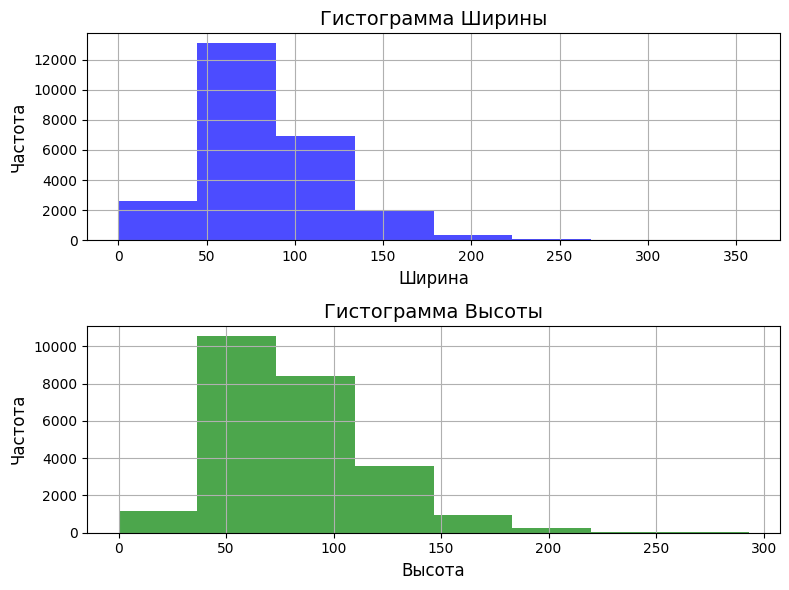

In [17]:
VAL_IMAGES_PATH = 'datasets/my_data_1/images/val/'
VAL_LABELS_PATH = 'datasets/my_data_1/labels/val/'

TRAIN_IMAGES_PATH = 'datasets/my_data_1/images/train/'
TRAIN_LABELS_PATH = 'datasets/my_data_1/labels/train/'


file_names_val = os.listdir(VAL_IMAGES_PATH)
file_names_train = os.listdir(TRAIN_IMAGES_PATH)

width_list = []
height_list = []


for file_name in tqdm(file_names_val, desc='Считывание размеров val'):
    image = cv2.imread(VAL_IMAGES_PATH + file_name)
    image_height, image_width, channels = image.shape
    with open(VAL_LABELS_PATH + file_name.replace('.jpg', '.txt'), 'r') as f:
        for annot in f.readlines():
            width_list.append(float(annot.split()[3]) * image_width)
            height_list.append(float(annot.split()[4]) * image_height)

for file_name in tqdm(file_names_train, desc='Считывание размеров train'):
    image = cv2.imread(TRAIN_IMAGES_PATH + file_name)
    image_height, image_width, channels = image.shape
    with open(TRAIN_LABELS_PATH + file_name.replace('.jpg', '.txt'), 'r') as f:
        for annot in f.readlines():
            width_list.append(float(annot.split()[3]) * image_width)
            height_list.append(float(annot.split()[4]) * image_height)



fig, axes = plt.subplots(2, 1, figsize=(8, 6))

# Гистограмма для width_list
axes[0].hist(width_list, bins=8, color='blue', alpha=0.7)
axes[0].set_title('Гистограмма Ширины', fontsize=14)
axes[0].set_xlabel('Ширина', fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)
axes[0].grid()  # Убираем сетку

# Гистограмма для height_list
axes[1].hist(height_list, bins=8, color='green', alpha=0.7)
axes[1].set_title('Гистограмма Высоты', fontsize=14)
axes[1].set_xlabel('Высота', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)
axes[1].grid()  # Убираем сетку


plt.tight_layout()
plt.show()

## Выведем общее количество людей, а также средние и медианные значения ширины/высоты человека ##

In [18]:
VAL_LABELS_PATH = 'datasets/my_data_1/labels/val/'
TRAIN_LABELS_PATH = 'datasets/my_data_1/labels/train/'


val_f = os.listdir(VAL_LABELS_PATH)
train_f = os.listdir(TRAIN_LABELS_PATH)
all_people = 0

for i in val_f:
    with open(VAL_LABELS_PATH + i, 'r') as f:
        all_people += len(f.readlines())

for i in train_f:
    with open(TRAIN_LABELS_PATH + i, 'r') as f:
        all_people += len(f.readlines())

print('Всего людей', all_people)



print('Медиана ширины', np.median(width_list))
print('Медиана высоты', np.median(height_list))

print('Среднее ширины', np.mean(width_list))
print('Среднее высоты', np.mean(height_list))

Всего людей 25016
Медиана ширины 76.57516799999999
Медиана высоты 75.998784
Среднее ширины 83.30903801598978
Среднее высоты 82.04866517388871


# Проверяем зависимость confidence от height*width наших bound=box'ов для каждой модели YOLO #

In [2]:
import contextlib
import gc

@contextlib.contextmanager
def clear_memory():
    try:
        yield
    finally:
        gc.collect()


TEST_IMAGES_PATH = 'datasets/my_data_1/images/val/'
file_names = os.listdir(TEST_IMAGES_PATH)


models = [
    YOLO('final_test/yolo_n-640x640-no_aug/weights/best.pt'),
    YOLO('final_test/yolo_n-1280x1280-no_aug/weights/best.pt'),
    YOLO('final_test/yolo_n-2080x2080-no_aug/weights/best.pt'),
    YOLO('final_test/yolo_n-3000x3000-no_aug/weights/best.pt'),
    YOLO('final_test/yolo_s-1280x1280-no_aug/weights/best.pt')
]


models_dict = {
    'width': [],
    'height': [],
    'original_box_size': [],
    'confidence': []
}


for model_num, model in enumerate(models):
    with clear_memory():
        list_of_width = []
        list_of_height = []
        list_of_confidence = []
        list_of_box_sizes = []
        
        for img_num, file_name in enumerate(file_names):
            print(f"\n\n\nCURRENT MODEL: {model_num}\tCURRENT IMAGE: {img_num}")
            result = model(TEST_IMAGES_PATH + file_name, device='0')
        
            for image in result:
                for num_box, box in enumerate(image.boxes.xywhn):
                    list_of_width.append(image.orig_img.shape[1] * box[2].item())
                    list_of_height.append(image.orig_img.shape[0] * box[3].item())
                    list_of_box_sizes.append(list_of_width[-1] * list_of_height[-1])
                    print(f'conf:{image.boxes.conf.cpu().numpy()[num_box]}\tsize: {list_of_box_sizes[-1]}')
                    
                list_of_confidence.extend(image.boxes.conf.cpu().numpy())
            #result[0].show()
            
        print('\n\n\n')
            
        models_dict['width'].append(list_of_width)
        models_dict['height'].append(list_of_height)
        models_dict['original_box_size'].append(list_of_box_sizes)
        models_dict['confidence'].append(list_of_confidence)






CURRENT MODEL: 0	CURRENT IMAGE: 0

image 1/1 C:\Anaconda_notebooks\datasets\my_data_1\images\val\1018.jpg: 480x640 4 humans, 29.4ms
Speed: 4.3ms preprocess, 29.4ms inference, 47.8ms postprocess per image at shape (1, 3, 480, 640)
conf:0.30311521887779236	size: 6950.537839363568
conf:0.2872540056705475	size: 5445.645381891022
conf:0.26287713646888733	size: 6642.591691681855
conf:0.25069165229797363	size: 7995.557815848151



CURRENT MODEL: 0	CURRENT IMAGE: 1

image 1/1 C:\Anaconda_notebooks\datasets\my_data_1\images\val\1023.jpg: 480x640 1 human, 3.2ms
Speed: 3.9ms preprocess, 3.2ms inference, 2.9ms postprocess per image at shape (1, 3, 480, 640)
conf:0.30331185460090637	size: 4557.638585470114



CURRENT MODEL: 0	CURRENT IMAGE: 2

image 1/1 C:\Anaconda_notebooks\datasets\my_data_1\images\val\1025.jpg: 480x640 1 human, 5.1ms
Speed: 0.9ms preprocess, 5.1ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)
conf:0.5221979022026062	size: 6696.983257882469



CURRENT MODEL:

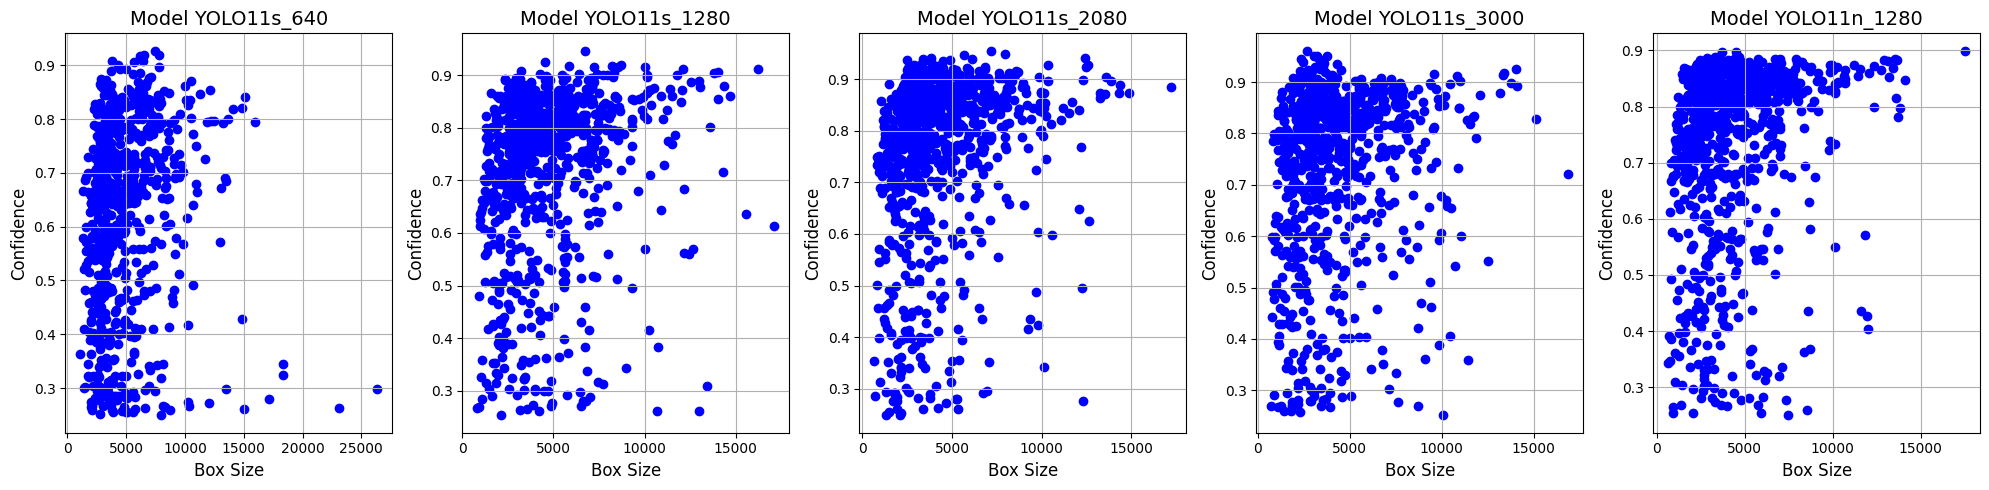

Box_sizes/conf correlation
Model YOLO11s_640: 0.09883036971649099
Model YOLO11s_1280: 0.17124992472774836
Model YOLO11s_2080: 0.2118106299284232
Model YOLO11s_3000: 0.1473588640273728
Model YOLO11n_1280: 0.1861109013348661


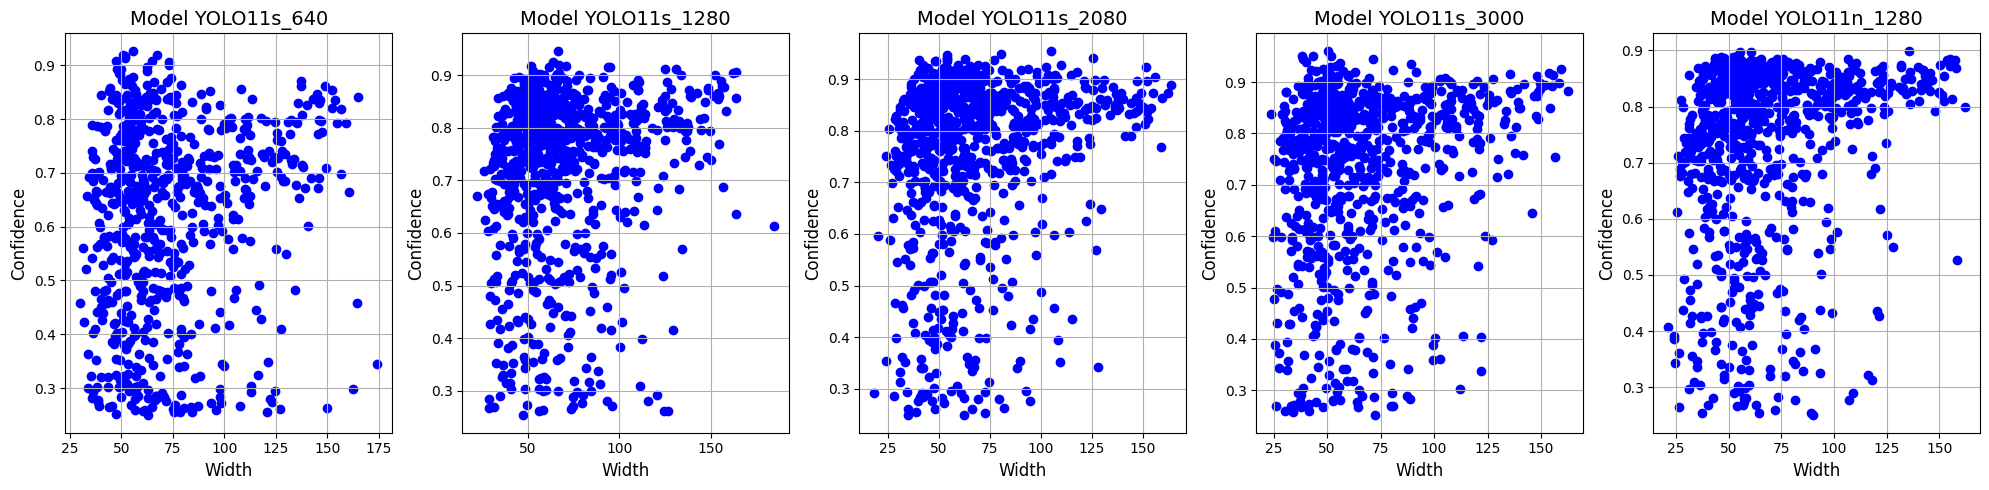

Width/conf correlation
Model YOLO11s_640: 0.13440061295408953
Model YOLO11s_1280: 0.1454371405385342
Model YOLO11s_2080: 0.18653676103086755
Model YOLO11s_3000: 0.18879769357154377
Model YOLO11n_1280: 0.18132384637879426


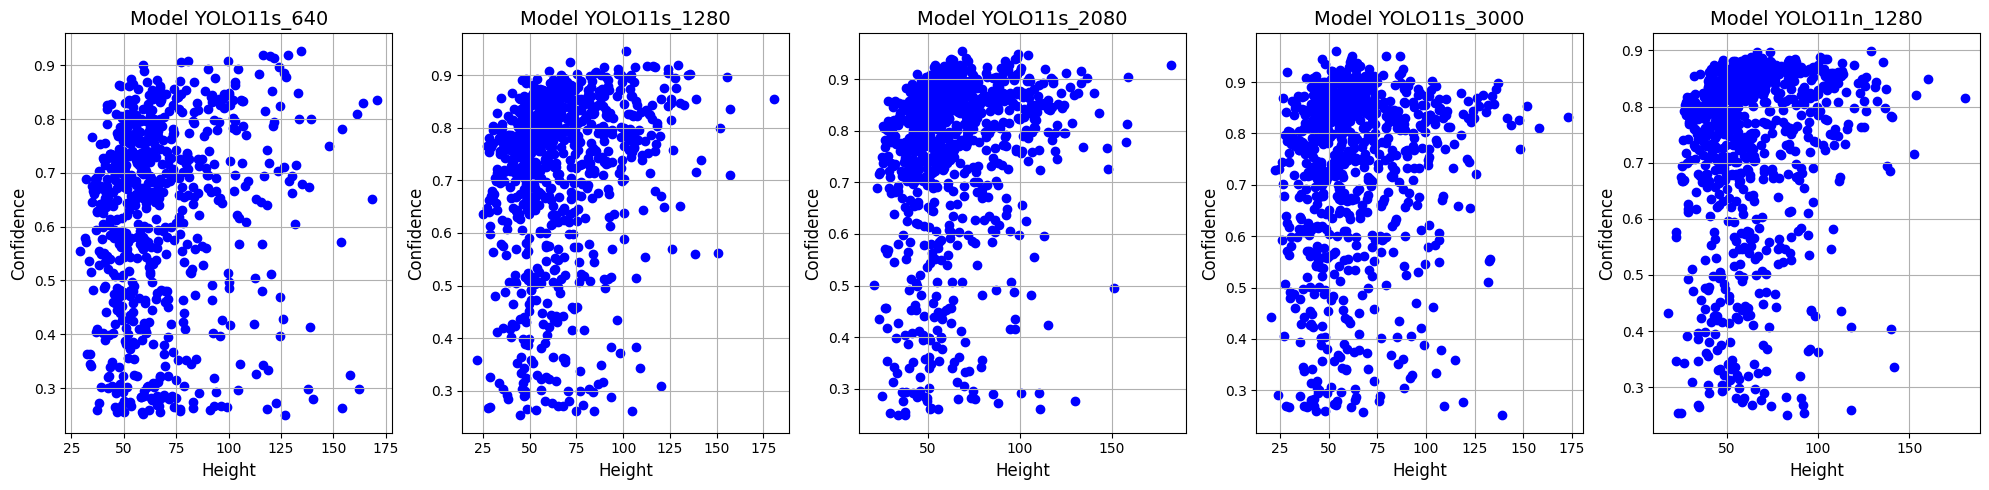

Height/conf correlation
Model YOLO11s_640: 0.10436390673182987
Model YOLO11s_1280: 0.16219842842058493
Model YOLO11s_2080: 0.16831196930002268
Model YOLO11s_3000: 0.08685613791300491
Model YOLO11n_1280: 0.11690728209212442


In [3]:
# Преобразование в hist_list
hist_list = []
for i in range(len(models_dict['confidence'])):  # У вас 5 элементов, поэтому используем диапазон от 0 до 4
    hist_list.append({
        'size': models_dict['original_box_size'][i],
        'conf': models_dict['confidence'][i],
        'width': models_dict['width'][i],
        'height': models_dict['height'][i],
    })


model_names = [
    'YOLO11s_640',
    'YOLO11s_1280',
    'YOLO11s_2080',
    'YOLO11s_3000',
    'YOLO11n_1280'
]



# ЗАВИСИМОСТЬ УВЕРЕННОСТИ ОТ РАЗМЕРА

fig, axes = plt.subplots(1, 5, figsize=(20, 5))  # Размер: ширина 10, высота 25
# Проходим по hist_list и строим графики
for i in range(5):
    box_sizes = hist_list[i]['size']  # Получаем значения box_size для i-го графика
    confidences = hist_list[i]['conf']  # Получаем значения confidence

    # Строим график
    axes[i].scatter(box_sizes, confidences, color='blue')  # Точечный график
    axes[i].set_title(f'Model {model_names[i]}', fontsize=14)  # Заголовок графика с увеличенным шрифтом
    axes[i].set_xlabel('Box Size', fontsize=12)  # Подпись оси X с увеличенным шрифтом
    axes[i].set_ylabel('Confidence', fontsize=12)  # Подпись оси Y с увеличенным шрифтом
    axes[i].grid()  # Добавляем сетку для удобства
    axes[i].tick_params(axis='both', labelsize=10)  # Увеличиваем размер меток на осях
plt.tight_layout()  # Уплотняем макет
plt.show()  # Показываем графики

# Также посмотрим на корреляционную зависимость conf от box_size 
print('Box_sizes/conf correlation')
for i in range(len(hist_list)):
    print(f'Model {model_names[i]}: {np.corrcoef(hist_list[i]['size'], hist_list[i]['conf'])[0, 1]}')




# ЗАВИСИМОСТЬ УВЕРЕННОСТИ ОТ ШИРИНЫ

fig, axes = plt.subplots(1, 5, figsize=(20, 5))  # Размер: ширина 10, высота 25
# Проходим по hist_list и строим графики
for i in range(5):
    width = hist_list[i]['width']
    confidences = hist_list[i]['conf']  # Получаем значения confidence

    # Строим график
    axes[i].scatter(width, confidences, color='blue')  # Точечный график
    axes[i].set_title(f'Model {model_names[i]}', fontsize=14)  # Заголовок графика с увеличенным шрифтом
    axes[i].set_xlabel('Width', fontsize=12)  # Подпись оси X с увеличенным шрифтом
    axes[i].set_ylabel('Confidence', fontsize=12)  # Подпись оси Y с увеличенным шрифтом
    axes[i].grid()  # Добавляем сетку для удобства
    axes[i].tick_params(axis='both', labelsize=10)  # Увеличиваем размер меток на осях
plt.tight_layout()  # Уплотняем макет
plt.show()  # Показываем графики

# Также посмотрим на корреляционную зависимость conf от width 
print('Width/conf correlation')
for i in range(len(hist_list)):
    print(f'Model {model_names[i]}: {np.corrcoef(hist_list[i]['width'], hist_list[i]['conf'])[0, 1]}')




# ЗАВИСИМОСТЬ УВЕРЕННОСТИ ОТ ВЫСОТЫ

fig, axes = plt.subplots(1, 5, figsize=(20, 5))  # Размер: ширина 10, высота 25
# Проходим по hist_list и строим графики
for i in range(5):
    height = hist_list[i]['height']
    confidences = hist_list[i]['conf']  # Получаем значения confidence

    # Строим график
    axes[i].scatter(height, confidences, color='blue')  # Точечный график
    axes[i].set_title(f'Model {model_names[i]}', fontsize=14)  # Заголовок графика с увеличенным шрифтом
    axes[i].set_xlabel('Height', fontsize=12)  # Подпись оси X с увеличенным шрифтом
    axes[i].set_ylabel('Confidence', fontsize=12)  # Подпись оси Y с увеличенным шрифтом
    axes[i].grid()  # Добавляем сетку для удобства
    axes[i].tick_params(axis='both', labelsize=10)  # Увеличиваем размер меток на осях
plt.tight_layout()  # Уплотняем макет
plt.show()  # Показываем графики

# Также посмотрим на корреляционную зависимость conf от width 
print('Height/conf correlation')
for i in range(len(hist_list)):
    print(f'Model {model_names[i]}: {np.corrcoef(hist_list[i]['height'], hist_list[i]['conf'])[0, 1]}')

# ОБУЧЕНИЕ FASTER-RCNN #
Опишем два собственных класса, реализующих нужные преобразования над датасетом.

In [ ]:
# Настройка преобразований
class ResizeKeepingAspectRatio:
    def __init__(self, target_width):
        self.target_width = target_width

    
    def __call__(self, img):
        # Получаем оригинальные размеры
        orig_width, orig_height = img.size
        
        # Вычисляем коэффициент масштабирования и новую высоту
        scale_factor = self.target_width / orig_width
        new_height = int(orig_height * scale_factor)
        
        # Изменяем размер изображения
        return img.resize((self.target_width, new_height), Image.LANCZOS)


class CustomYOLODataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform
        self.images = [img for img in os.listdir(images_dir) if img.endswith('.jpg')]  # Фильтруем только .jpg файлы

    
    def __len__(self):
        return len(self.images)

    
    def __getitem__(self, idx):
        # Загрузка изображения
        img_name = os.path.join(self.images_dir, self.images[idx])
        image = Image.open(img_name).convert("RGB")
       
        # Трансформация изображения
        image = self.transform(image)

        # Загрузка аннотации
        label_name = os.path.join(self.labels_dir, self.images[idx].replace('.jpg', '.txt'))
        boxes = []  # Список для хранения координат объектов
        with open(label_name, 'r') as file:
            for line in file:
                class_id, x, y, w, h = map(float, line.split())  # Чтение аннотации
                # Преобразование координат в формате COCO
                xmin = int(x * image.shape[2] - (w * image.shape[2]) / 2)
                ymin = int(y * image.shape[1] - (h * image.shape[1]) / 2)
                xmax = int(xmin + w * image.shape[2])
                ymax = int(ymin + h * image.shape[1])
                boxes.append([xmin, ymin, xmax, ymax, class_id + 1])

        # Преобразуем координаты в тензоры
        if boxes:
            boxes = torch.tensor(boxes, dtype=torch.float32).to(device)
        else:
            boxes = torch.empty((0, 5)).to(device)

        # Добавляем боксы и лейблы в аннотацию
        target = {
            'boxes': boxes[:, :4],  # Координаты
            'labels': boxes[:, 4].long()  # Метки классов
        }

        return image, target



# Рисуем изображение вместе с боксами
def save_image(batch_images, batch_pred, batch_orig, save_path=None, epoch=None):
    
    # Сохраняем все картинки текущего Батча  
    for img_num, (image, boxes_pred, boxes_orig) in enumerate(zip(batch_images, batch_pred, batch_orig)):

        
        # Сохраняем оригинальное изображение
        image_orig = Image.fromarray((image.permute(1, 2, 0).cpu().numpy() * 255).astype('uint8'))  # Приводим значение к диапазону 0-255 и меняем порядок осей
        draw_orig = ImageDraw.Draw(image_orig)
        for box in boxes_orig['boxes']:
            if type(box) == list:
                print(box)
                xmin, ymin, xmax, ymax, _ = box
            else:
                xmin, ymin, xmax, ymax = box.tolist()  # Конвертируем тензор в список
            draw_orig.rectangle([xmin, ymin, xmax, ymax], outline="red", width=1)


        # Сохраняем предсказанное изображение
        image_pred = Image.fromarray((image.permute(1, 2, 0).cpu().numpy() * 255).astype('uint8'))  # Приводим значение к диапазону 0-255 и меняем порядок осей
        draw_pred = ImageDraw.Draw(image_pred)
        for box in boxes_pred['boxes']:
            if type(box) == list:
                print(box)
                xmin, ymin, xmax, ymax, _ = box
            else:
                xmin, ymin, xmax, ymax = box.tolist()  # Конвертируем тензор в список
            draw_pred.rectangle([xmin, ymin, xmax, ymax], outline="red", width=1)

        
        # Сохраняем картинки если указан путь
        if save_path:
            image_orig.save(save_path + 'epoch' + str(epoch) + '_batch'+ str(img_num) + '_ORIG.jpg')
            image_pred.save(save_path + 'epoch' + str(epoch) + '_batch'+ str(img_num) + '_PRED.jpg')
    print(f"Изображения сохранены в: {save_path}")



# Выполняем рассчет метрик на валидационной выборке
def calculate_metrics(all_preds, all_targets):
    # Порог IoU
    iou_threshold = 0.5
    
    # Переменные для накопления TP, FP, FN для всей выборки
    total_TP = 0
    total_FP = 0
    total_FN = 0
    
    # Обработка батчей и изображений
    for pred_batch, target_batch in zip(all_preds, all_targets):
        for pred_img, target_img in zip(pred_batch, target_batch):
            # Расчет IoU
            iou_matrix = box_iou(pred_img['boxes'], target_img['boxes'])
    
            # TP, FP, FN для текущего изображения
            TP = 0
            FP = 0
            FN = len(target_img['boxes'])
            used_target_indices = []
    
            # Проверка каждого предсказанного бокса
            for pred_idx, (pred_box, pred_label) in enumerate(zip(pred_img['boxes'], pred_img['labels'])):
                max_iou, max_iou_idx = iou_matrix[pred_idx].max(), iou_matrix[pred_idx].argmax()
    
                # Проверяем условия для истинного положительного
                if max_iou >= iou_threshold and pred_label == target_img['labels'][max_iou_idx]:
                    if max_iou_idx.item() not in used_target_indices:  # Убедитесь, что этот целевой бокс не использовался ранее
                        TP += 1
                        used_target_indices.append(max_iou_idx.item())
                        FN -= 1  # Уменьшить количество FN, так как одно целевое значение теперь найдено
                else:
                    FP += 1
    
            # Накопление общих метрик для всей выборки
            total_TP += TP
            total_FP += FP
            total_FN += FN

    # Вычисление метрик для всей выборки
    precision = total_TP / (total_TP + total_FP + 1e-7)
    recall = total_TP / (total_TP + total_FN + 1e-7)

    return {
        'precision': precision, 
        'recal': recall
    }

In [13]:
# Преобразования
transform = transforms.Compose([
    ResizeKeepingAspectRatio(1280),  # Изменение размера изображений
    transforms.ToTensor()
])


# Указываем пути к данным
train_image_dir = 'C:/Users/mrsli/myNotebooks/Pattern_Project/datasets/my_data_1/images/train'
train_label_dir = 'C:/Users/mrsli/myNotebooks/Pattern_Project/datasets/my_data_1/labels/train'

val_image_dir = 'C:/Users/mrsli/myNotebooks/Pattern_Project/datasets/my_data_1/images/val'
val_label_dir = 'C:/Users/mrsli/myNotebooks/Pattern_Project/datasets/my_data_1/labels/val'


# Параметры
num_classes = 2  # Измените на количество классов в вашем датасете
batch_size = 6
num_epochs = 30


# Создание train датасета и загрузчика данных
train_dataset = CustomYOLODataset(images_dir=train_image_dir, labels_dir=train_label_dir, transform=transform)
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# Создание val датасета и загрузчика данных
val_dataset = CustomYOLODataset(images_dir=val_image_dir, labels_dir=val_label_dir, transform=transform)
val_data_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))








# Создаем и описываем модель MobileNetv3 Faster-RCNN
model = models.detection.fasterrcnn_mobilenet_v3_large_fpn(weights='FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT')
model.load_state_dict(torch.load('faster_rcnn_mobilenet_v3.pth'))
model = models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=False)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)



# Переводим модель на наш дЕвАйс
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


# Определение оптимизатора
params = [p for p in model.parameters() if p.requires_grad]
#optimizer = torch.optim.AdamW(params)


optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.00001, nesterov=True)
#lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.99)


# Обучение
for epoch in range(num_epochs):
    model.train()

    
    epoch_losses = {
        'loss_classifier': [],
        'loss_box_reg': [],
        'loss_objectness': [],
        'loss_rpn_box_reg': []
    }
    

    
    epoch_losses = {
        'classification': [],
        'bbox_regression': [],
    }
    
    
    for images, targets in tqdm(train_data_loader, desc=f'train Epoch {epoch + 1}/{num_epochs}'):
        images = [image.to(device) for image in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]



        optimizer.zero_grad()
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values()).to(device)
        
        losses.backward()
        optimizer.step()


        for key in loss_dict.keys():
            epoch_losses[key].append(loss_dict[key].cpu().item())

    #if lr_scheduler is not None:
    #    lr_scheduler.step()
    
    for key in epoch_losses.keys():
        print(key, ':', np.mean(epoch_losses[key]))


    # Валидация
    model.eval()
    all_preds = []
    all_targets = []
    bathc_num = 0
    
    with torch.no_grad():
        for val_images, val_targets in tqdm(val_data_loader, desc=f'val Epoch {epoch + 1}/{num_epochs}'):
            val_images = [image.to(device) for image in val_images]
            val_outputs = model(val_images)

            if bathc_num == 3:
                save_image(val_images, val_outputs, val_targets,save_path='final_test/fasterrcnn_mobilenet_v3_large_fpn_1280x1280/preds/', epoch=epoch)
            bathc_num +=1

            all_preds.append(val_outputs)
            all_targets.append(val_targets)
    
    # Расчет метрик после валидации
    metrics = calculate_metrics(all_preds, all_targets)
    print(metrics)




torch.save(model.state_dict(), 'faster_rcnn_mobilenet_v3_2333.pth')

train Epoch 1/30: 100%|██████████| 182/182 [05:50<00:00,  1.93s/it]


classification : 2.2943569736166314
bbox_regression : 1.862978872362074


val Epoch 1/30:   9%|▊         | 4/46 [00:06<01:08,  1.62s/it]

Изображения сохранены в: final_test/fasterrcnn_mobilenet_v3_large_fpn_1280x1280/preds/


val Epoch 1/30: 100%|██████████| 46/46 [01:20<00:00,  1.76s/it]


...

Изображения сохранены в: final_test/fasterrcnn_mobilenet_v3_large_fpn_1280x1280/preds/


val Epoch 5/30: 100%|██████████| 46/46 [01:14<00:00,  1.61s/it]


{'precision': 0.011216771919497692, 'recal': 0.7352587243399208, 'map50': None, 'map50-95': None}


train Epoch 6/30:   1%|          | 2/182 [00:05<07:37,  2.54s/it]


KeyboardInterrupt: 